# Main for Energy Simulation 

Simulates the energy consumption for each track, calculates the SoC each truck would have and calculates the resulting load profiles for the freight forwarding locations 

This notebook is to be executed after data/data_handling/data-aquisition.ipynb and main_data_analysis.ipynb

### Imports 

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import sys

sys.path.append('energy_sim')
import data.data_handling.data_visualization as dv
import data.data_handling.data_processing as dp
from data.data_handling.data_processing import colors_fleets, alpha_major, alpha_minor
import energy_sim.BETOS_Framework
from energy_sim.energy_sim_functions import faulty_tracks, run_energy_sim, clean_energy_sim_data
import data.data_handling.sequential_analysis as sq

## Perform Energy Simulation based on BET.OS script 

The energy simulation takes very long to run (in total approx. 24 h) and should just only be executed once 

First run the faulty_tracks() function to identify tracks with missing data (results will be saved in mismatched_tracks.csv)
Then run run_energy_sim() to calculate energy consumption for each track (results will be saved in tracks_filtered_with_energy.csv)
Run run_energy_sim() will additionally create zero_speed_tracks.csv which lists tracks that have no speed data

The outputs are saved as csvs

### Run once:

In [ ]:
#faulty_tracks()

trips_energy = run_energy_sim(override_mismatched_tracks=False)

"Can either pass on trips_energy directly from the simulation or let the function read in tracks_with_energy_raw.csv"
#df_trip_energy = clean_energy_sim_data(trips=None)

### After running the energy simulation once, read the csv instead of excecuting the simulation

In [2]:
df_trip_energy= pd.read_csv('data/output/csvs/tracks_with_energy.csv', index_col='track_id')

In [3]:
df_trips = pd.read_csv('input/stations/tracks_filtered.csv', index_col='track_id')
df_trips['stop_time'] = pd.to_datetime(df_trips['stop_time'], format='ISO8601')
df_trips['start_time'] = pd.to_datetime(df_trips['start_time'], format='ISO8601')

df_stops = dp.process_stops_data(df_trips)
df_occ_energy = sq.combine_tracks_and_stops(df_stops = df_stops, df_tracks_with_energy = df_trip_energy)

 Vehicle ID: 1
 Vehicle ID: 2
 Vehicle ID: 3
 Vehicle ID: 4
 Vehicle ID: 5
 Vehicle ID: 6
 Vehicle ID: 7
 Vehicle ID: 8
 Vehicle ID: 9
 Vehicle ID: 10
 Vehicle ID: 11
 Vehicle ID: 12
 Vehicle ID: 13
 Vehicle ID: 14
 Vehicle ID: 15
 Vehicle ID: 16
 Vehicle ID: 17
 Vehicle ID: 18
 Vehicle ID: 19
 Vehicle ID: 20
 Vehicle ID: 21
 Vehicle ID: 22
 Vehicle ID: 23
 Vehicle ID: 24
 Vehicle ID: 25
 Vehicle ID: 26
 Vehicle ID: 27
 Vehicle ID: 28
 Vehicle ID: 29
 Vehicle ID: 30
 Vehicle ID: 31
 Vehicle ID: 32
 Vehicle ID: 33
 Vehicle ID: 34
 Vehicle ID: 35
 Vehicle ID: 36
 Vehicle ID: 37
 Vehicle ID: 38
 Vehicle ID: 39
 Vehicle ID: 40
 Vehicle ID: 41
 Vehicle ID: 42
 Vehicle ID: 43
 Vehicle ID: 44
 Vehicle ID: 45
 Vehicle ID: 46
 Vehicle ID: 47
 Vehicle ID: 48
 Vehicle ID: 49
 Vehicle ID: 50
 Vehicle ID: 51
 Vehicle ID: 52
 Vehicle ID: 53
 Vehicle ID: 54
 Vehicle ID: 55
 Vehicle ID: 56
 Vehicle ID: 57
 Vehicle ID: 58
 Vehicle ID: 59
 Vehicle ID: 60
 Vehicle ID: 61
 Vehicle ID: 62
 Vehicle ID: 63
 

### Calculate Battery charges and SoCs at the end of each activity *

In [4]:
# Constant charging powers 
charging_powers = {'home base': 50, 'industrial area': 350}
df_soc, public_charging = sq.truck_soc(df_activities = df_occ_energy, charging_powers = charging_powers, soc_min = 0.15)

Freight Forwarder 1:
  Instances with soc < soc_min: 1445
  Percentage: 10.50% 

Freight Forwarder 2:
  Instances with soc < soc_min: 5
  Percentage: 0.07% 

Freight Forwarder 3:
  Instances with soc < soc_min: 99
  Percentage: 1.28% 

Freight Forwarder 4:
  Instances with soc < soc_min: 3093
  Percentage: 28.70% 

Freight Forwarder 5:
  Instances with soc < soc_min: 2597
  Percentage: 14.35% 

Freight Forwarder 6:
  Instances with soc < soc_min: 3247
  Percentage: 11.73% 

Without considering public charging:
Energy recharged at industrial areas: 1279109.81 kWh
Energy recharged at home bases: 882225.58 kWh
Total energy recharged at private areas: 2161335.39 kWh


Considering public charging:
Total energy recharged publicly: 333560.90 kWh
Total energy recharged privately, when using public charging: 2098001.94 kWh
Total energy recharged at home bases, when using public charging: 860781.69 kWh
Total energy recharged at industrial areas, when using public charging: 1237220.24 kWh
Total e

### Tour statistics *

In [5]:
"""
In contrast to df_tours, df_tours_energy also includes non-driving activities between tracks. 
Thus, some additional parameters are included

    Stop time is the stop time of the last track equivalently to df_tours, 
    End time additionally includes the time spent at the home base after the tour's last track (i.e. = start time of the next tour)
   
    driving_duration is the sum of the duration of all driving activities in the tour, equivalently to duration in df_tours
    duration is the time between the start of the tour's first track and the end of its last activity 
     (i.e the duration between the start of the tour and the start of the next tour)
"""

df_tours_energy = dp.aggregate_tours(df_soc, charging_powers, save=True, energy=True, min_soc=0.15)

Freight Forwarder 1:
  Instances with soc < soc_min: 231
  Percentage: 12.55% 

Freight Forwarder 2:
  Instances with soc < soc_min: 4
  Percentage: 0.44% 

Freight Forwarder 3:
  Instances with soc < soc_min: 49
  Percentage: 2.97% 

Freight Forwarder 4:
  Instances with soc < soc_min: 427
  Percentage: 40.55% 

Freight Forwarder 5:
  Instances with soc < soc_min: 498
  Percentage: 16.55% 

Freight Forwarder 6:
  Instances with soc < soc_min: 658
  Percentage: 12.74% 




Freight Forwarder 1 - SoC Statistics:
soc_min: Mean=63.58%, Median=81.47%, Min=-254.17%, Max=90.00%
  soc_min outliers below -50%: 75 (minimum: -254.17%)
soc_at_departure: Mean=86.45%, Median=90.00%, Min=-140.90%, Max=90.00%
  soc_at_departure outliers below -50%: 8 (minimum: -140.90%)
soc_at_arrival: Mean=76.40%, Median=84.90%, Min=-236.39%, Max=90.00%
  soc_at_arrival outliers below -50%: 23 (minimum: -236.39%)

Freight Forwarder 2 - SoC Statistics:
soc_min: Mean=66.75%, Median=63.17%, Min=-7.30%, Max=90.00%
soc_at_departure: Mean=82.94%, Median=90.00%, Min=6.92%, Max=90.00%
soc_at_arrival: Mean=70.19%, Median=73.22%, Min=-7.30%, Max=90.00%

Freight Forwarder 3 - SoC Statistics:
soc_min: Mean=68.32%, Median=75.65%, Min=-18.92%, Max=90.00%
soc_at_departure: Mean=83.87%, Median=90.00%, Min=-17.09%, Max=90.00%
soc_at_arrival: Mean=70.27%, Median=77.34%, Min=-18.92%, Max=90.00%

Freight Forwarder 4 - SoC Statistics:
soc_min: Mean=10.93%, Median=31.78%, Min=-419.53%, Max=90.00%
  soc_min

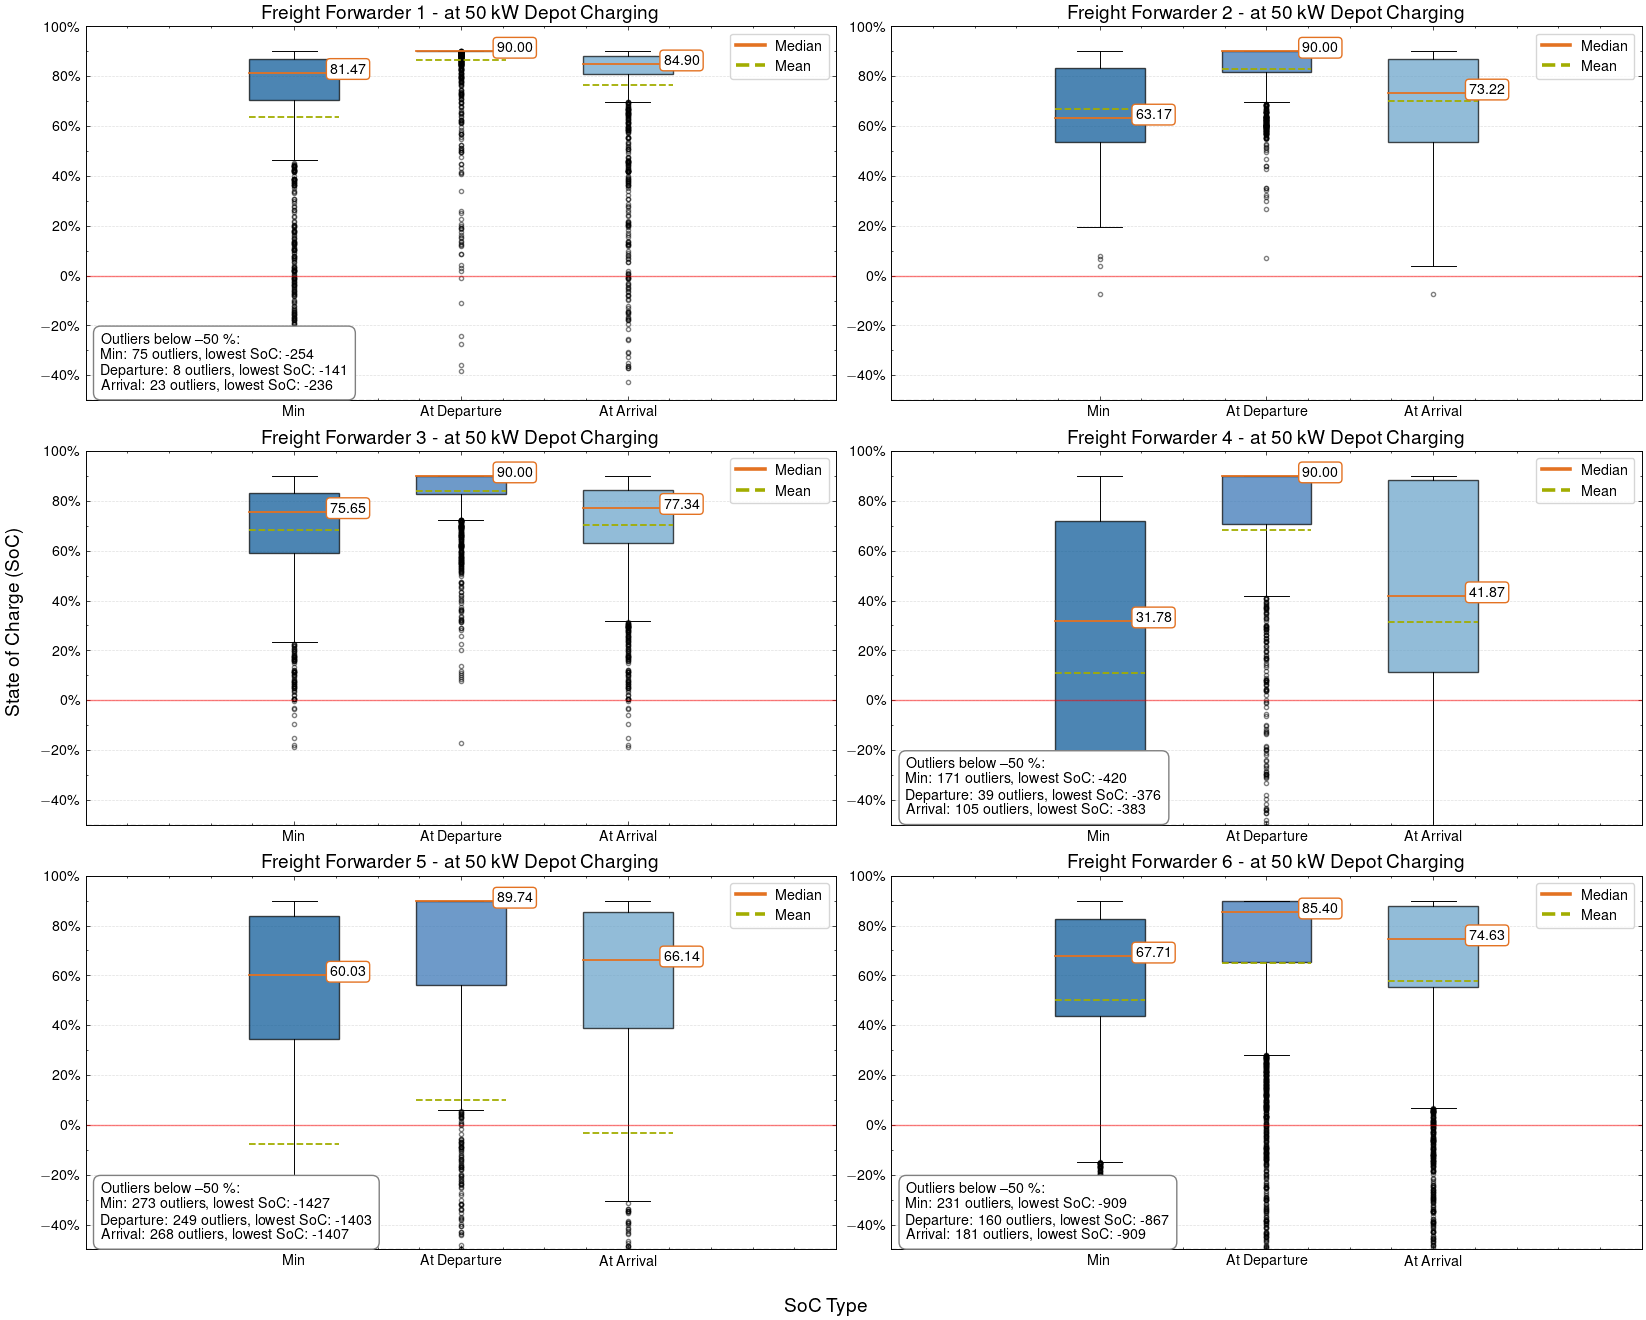

In [6]:
 # TODO adjust the plots into something meaninfull. Ideas:
# First See what the data looks like for different charging strategies. Then:
# 1) plot the amount (ratio of occurences to total tours) of SoCs below a certain threshold = 0.15
# 2) plot the distance travelled under the SoC threshold = 0.15
# 3) maybe try a cumulative density plot with SoC on x axis and the number of occurences on the y axis 
#    (SoC = 1 is the origen), up to threshold the plot is green, afterwards orange
# 4) try a histplot?? https://seaborn.pydata.org/examples/histogram_stacked.html 
#    (what could be important additional information? one plot with all ffs, or maybe length of tour?)

# TODO See alternative plot verion in notes for plot in the same format of weekly distance boxplot  
df_soc_plot = df_tours_energy.copy()
#result = dv.plot_soc_by_freight_forwarder_symlog(df_soc_plot)
result = dv.plot_soc_by_freight_forwarder(df_tours_energy = df_soc_plot, charging_powers=charging_powers)

## Freight Forwarding Location Analysis

### Energy recharged potential of each tour on its own
In contrast to the energy_recharged_kwh and energy_recharged_kwh_potential calculated by sq.truck_soc(), this function only considers the energy that can be recharged within a tour, i.e disregarding truck disposition. This is equivalent to the assumption that the SoC at the start of each tour = SoC max. 

In [7]:
tracks_energy_no_disp = dp.tracks_energy_con_and_regen(df_activities = df_occ_energy, charging_powers = charging_powers, soc_min=0.15)

Freight Forwarder 1:
  Instances with soc < soc_min: 1223
  Percentage: 8.89% 

Freight Forwarder 2:
  Instances with soc < soc_min: 4
  Percentage: 0.06% 

Freight Forwarder 3:
  Instances with soc < soc_min: 70
  Percentage: 0.91% 

Freight Forwarder 4:
  Instances with soc < soc_min: 2444
  Percentage: 22.68% 

Freight Forwarder 5:
  Instances with soc < soc_min: 64
  Percentage: 0.35% 

Freight Forwarder 6:
  Instances with soc < soc_min: 471
  Percentage: 1.70% 

Total energy recharged at industrial areas: 1046687.86 kWh
Total energy recharged potential at industrial areas: 1152395.68 kWh


### Tour statistics *

In [8]:
df_tours_energy_no_disp = dp.aggregate_tours(tracks_energy_no_disp, charging_powers, save=False, energy=True, min_soc=0.15)
df_tours_energy_no_disp.to_csv(f"data/output/track_energies/tours_constant_charging_{charging_powers['home base']}-{charging_powers['industrial area']}_no_disp.csv", index=False)

""" Print some statistics """
# Calculate the threshold
Battery_capacity = 572  # in kWh
max_dod = 0.75  # maximum depth of discharge
threshold = Battery_capacity * max_dod

# Tours with too high energy consumption
problematic_tours = df_tours_energy_no_disp[df_tours_energy_no_disp['energy_consumption_kwh_cleaned'] - df_tours_energy_no_disp['energy_recharged_kwh'] > threshold]
problematic_tours_wo_indu = df_tours_energy_no_disp[df_tours_energy_no_disp['energy_consumption_kwh_cleaned'] > threshold]


# Calculate absolute and percentage values
absolute_count = problematic_tours.shape[0]
percentage_count = (absolute_count / df_tours_energy_no_disp.shape[0]) * 100

# Print the results
print(f"Absolute number of tours with too high energy consumption: {absolute_count}")
print(f"Percentage of total tours: {percentage_count:.2f}%")

print(f"Absolute number of tours with too high energy consumption (without industrial area charging): {problematic_tours_wo_indu.shape[0]}")
print(f"Percentage of total tours (without industrial area charging): {(problematic_tours_wo_indu.shape[0] / df_tours_energy_no_disp.shape[0]) * 100:.2f}%")

print('\n')
energy_industrial = df_tours_energy_no_disp['energy_recharged_kwh'].sum()
required_energy = (problematic_tours['energy_consumption_kwh_cleaned'] - problematic_tours['energy_recharged_kwh']) - threshold
energy_public = required_energy.sum()
depot_charging = df_tours_energy_no_disp['energy_consumption_kwh_cleaned'] - df_tours_energy_no_disp['energy_recharged_kwh']
depot_charging = depot_charging.clip(upper=threshold)
energy_depot = depot_charging.sum()


total_energy = energy_industrial + energy_public + energy_depot
print(f"Total energy required from public charging: {energy_public:.2f} kWh")
print(f"Total energy required from industrial area charging: {energy_industrial:.2f} kWh")
print(f"Total energy required from depot charging: {energy_depot:.2f} kWh")

print('\n')
print(f"public charging percentage: {energy_public / total_energy * 100:.2f}%")
print(f"industrial area charging percentage: {energy_industrial / total_energy * 100:.2f}%")
print(f"depot charging percentage: {energy_depot / total_energy * 100:.2f}%")

Freight Forwarder 1:
  Instances with soc < soc_min: 212
  Percentage: 11.52% 

Freight Forwarder 2:
  Instances with soc < soc_min: 3
  Percentage: 0.33% 

Freight Forwarder 3:
  Instances with soc < soc_min: 30
  Percentage: 1.82% 

Freight Forwarder 4:
  Instances with soc < soc_min: 315
  Percentage: 29.91% 

Freight Forwarder 5:
  Instances with soc < soc_min: 8
  Percentage: 0.27% 

Freight Forwarder 6:
  Instances with soc < soc_min: 81
  Percentage: 1.57% 

Absolute number of tours with too high energy consumption: 473
Percentage of total tours: 3.47%
Absolute number of tours with too high energy consumption (without industrial area charging): 1191
Percentage of total tours (without industrial area charging): 8.75%


Total energy required from public charging: 172298.95 kWh
Total energy required from industrial area charging: 1046687.86 kWh
Total energy required from depot charging: 1227075.61 kWh


public charging percentage: 7.04%
industrial area charging percentage: 42.79%
d

### Daily Energy Demands per Home Base

In [9]:
daily_demands = dp.daily_energy_demands(df_tours_energy_no_disp, threshold, charging_powers)

print(daily_demands.head())

# Most critical for ff 4. Where we have a representative sample of 10% of all of the ff's trucks --> daily load profiles would be 10x of these results
# 90/135 or 66 % of all recorded days could not be served with one traffo even if we assume an even load profile throughout the day 
# (max recharge in a day with 1 traffo = 630 kW * 24h = 15120 kWh)

          day  energy_demand_kwh  cid  freight_forwarder
0  2021-09-07          12.578284    0                  1
1  2021-09-08         104.623538    0                  1
2  2021-09-09         106.343356    0                  1
3  2021-09-10         320.270202    0                  1
4  2021-09-12          10.688259    0                  1


### Charging Load Profiles per Home Base


Home Base CID 0 - Daily Energy Demand:
  weekday_name         mean         std       median  count
0       Monday   844.117121  355.263807   900.616159     21
1      Tuesday  1511.594583  484.653294  1604.266501     22
2    Wednesday  1017.278879  567.767094   964.342338     22
3     Thursday  1334.064814  731.942473  1270.239019     23
4       Friday  1412.914942  478.475035  1474.608724     20
5     Saturday   251.075619  239.827843   150.600915     10
6       Sunday     3.697288    3.277715     2.393341      7
Overall mean: 1078.72 kWh

Home Base CID 2 - Daily Energy Demand:
  weekday_name        mean         std      median  count
0       Monday  207.103766  116.300807  210.107032     21
1      Tuesday  239.558294  130.940388  205.616962     22
2    Wednesday  255.864864  147.692782  287.088924     23
3     Thursday  243.309430  182.263063  200.256690     22
4       Friday  370.649855  177.530488  391.749056     20
5     Saturday   96.848419   78.472170   96.848419      2
6       

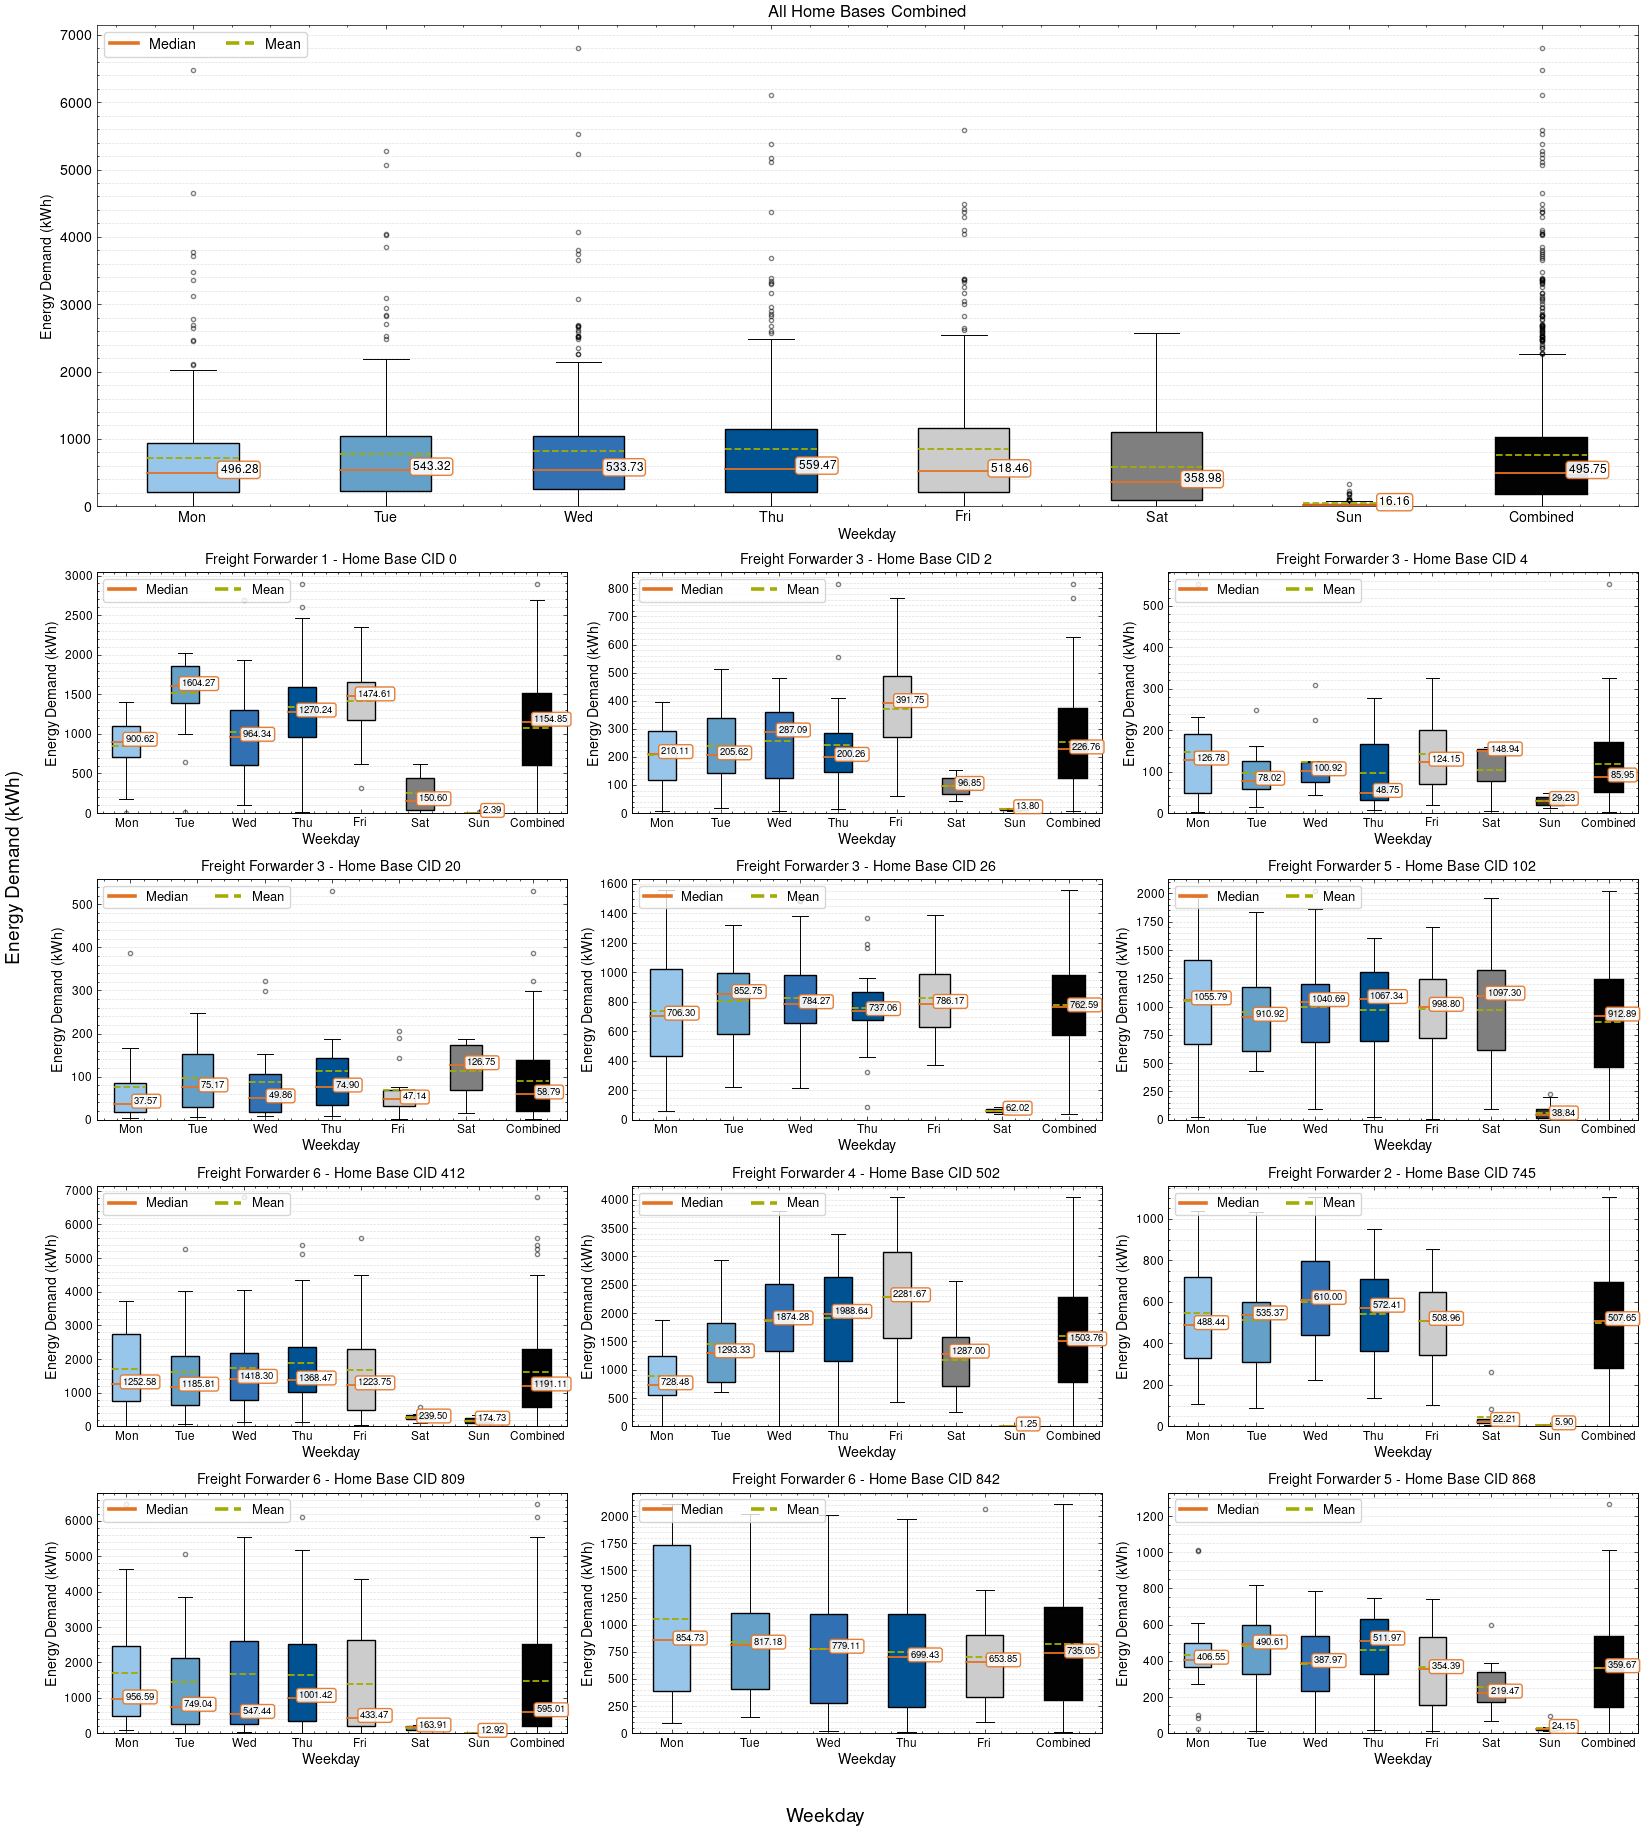

In [10]:
dv.plot_weekly_energy_demand_boxplot2(daily_demands)

## Create Load Profiles *

In [11]:
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
import data.data_handling.load_profile as lp

print(charging_powers)
# Call the function with the load threshold parameter (default is 630 kW)
load_profiles, charging_stats = lp.calculate_charging_load_profiles(
    df_tours_energy_no_disp, charging_powers, threshold, load_threshold=630, save=True)

charging_durations = {cid: stats['avg_charging_duration_min'] for cid, stats in charging_stats.items()}

# If you want to display the statistics after calculation
for cid, stats in charging_stats.items():
    print(f"CID {cid}:")
    print(f"  Average charging duration: {stats['avg_charging_duration_min']:.2f} minutes")
    print(f"  Max load: {stats['max_load_kW']:.2f} kW")
    print(f"  Average time above threshold per day: {stats['avg_minutes_above_threshold']:.2f} minutes")
    print("\n")
# inputs: charging powers, df_tours_energy_no_disp

# intermediate dfs (one for each cid)
#   rows: minutes
#   columns: "charging package" (i.e energy demand / consumption of arriving track - charging power * time)
#            if no charging package then all values in row are None 
# -> load = number of charging packages each minute * charging power


# output one df per cid:
#   rows: minutes
#   columns: date, freight_forwarder, current load in kW

{'home base': 50, 'industrial area': 350}
Processing cid: 0
Average charging duration for CID 0: 87.40 minutes
Max load for CID 0: 450.00 kW
Average time above 630 kW per day: 0.0 minutes
Freight Forwarder: 1

Processing cid: 745
Average charging duration for CID 745: 106.40 minutes
Max load for CID 745: 300.00 kW
Average time above 630 kW per day: 0.0 minutes
Freight Forwarder: 2

Processing cid: 26
Average charging duration for CID 26: 154.50 minutes
Max load for CID 26: 300.00 kW
Average time above 630 kW per day: 0.0 minutes
Freight Forwarder: 3

Processing cid: 4
Average charging duration for CID 4: 63.50 minutes
Max load for CID 4: 150.00 kW
Average time above 630 kW per day: 0.0 minutes
Freight Forwarder: 3

Processing cid: 2
Average charging duration for CID 2: 52.20 minutes
Max load for CID 2: 200.00 kW
Average time above 630 kW per day: 0.0 minutes
Freight Forwarder: 3

Processing cid: 20
Average charging duration for CID 20: 71.40 minutes
Max load for CID 20: 100.00 kW
Avera

Using thesis version of plot_load_profiles_grid


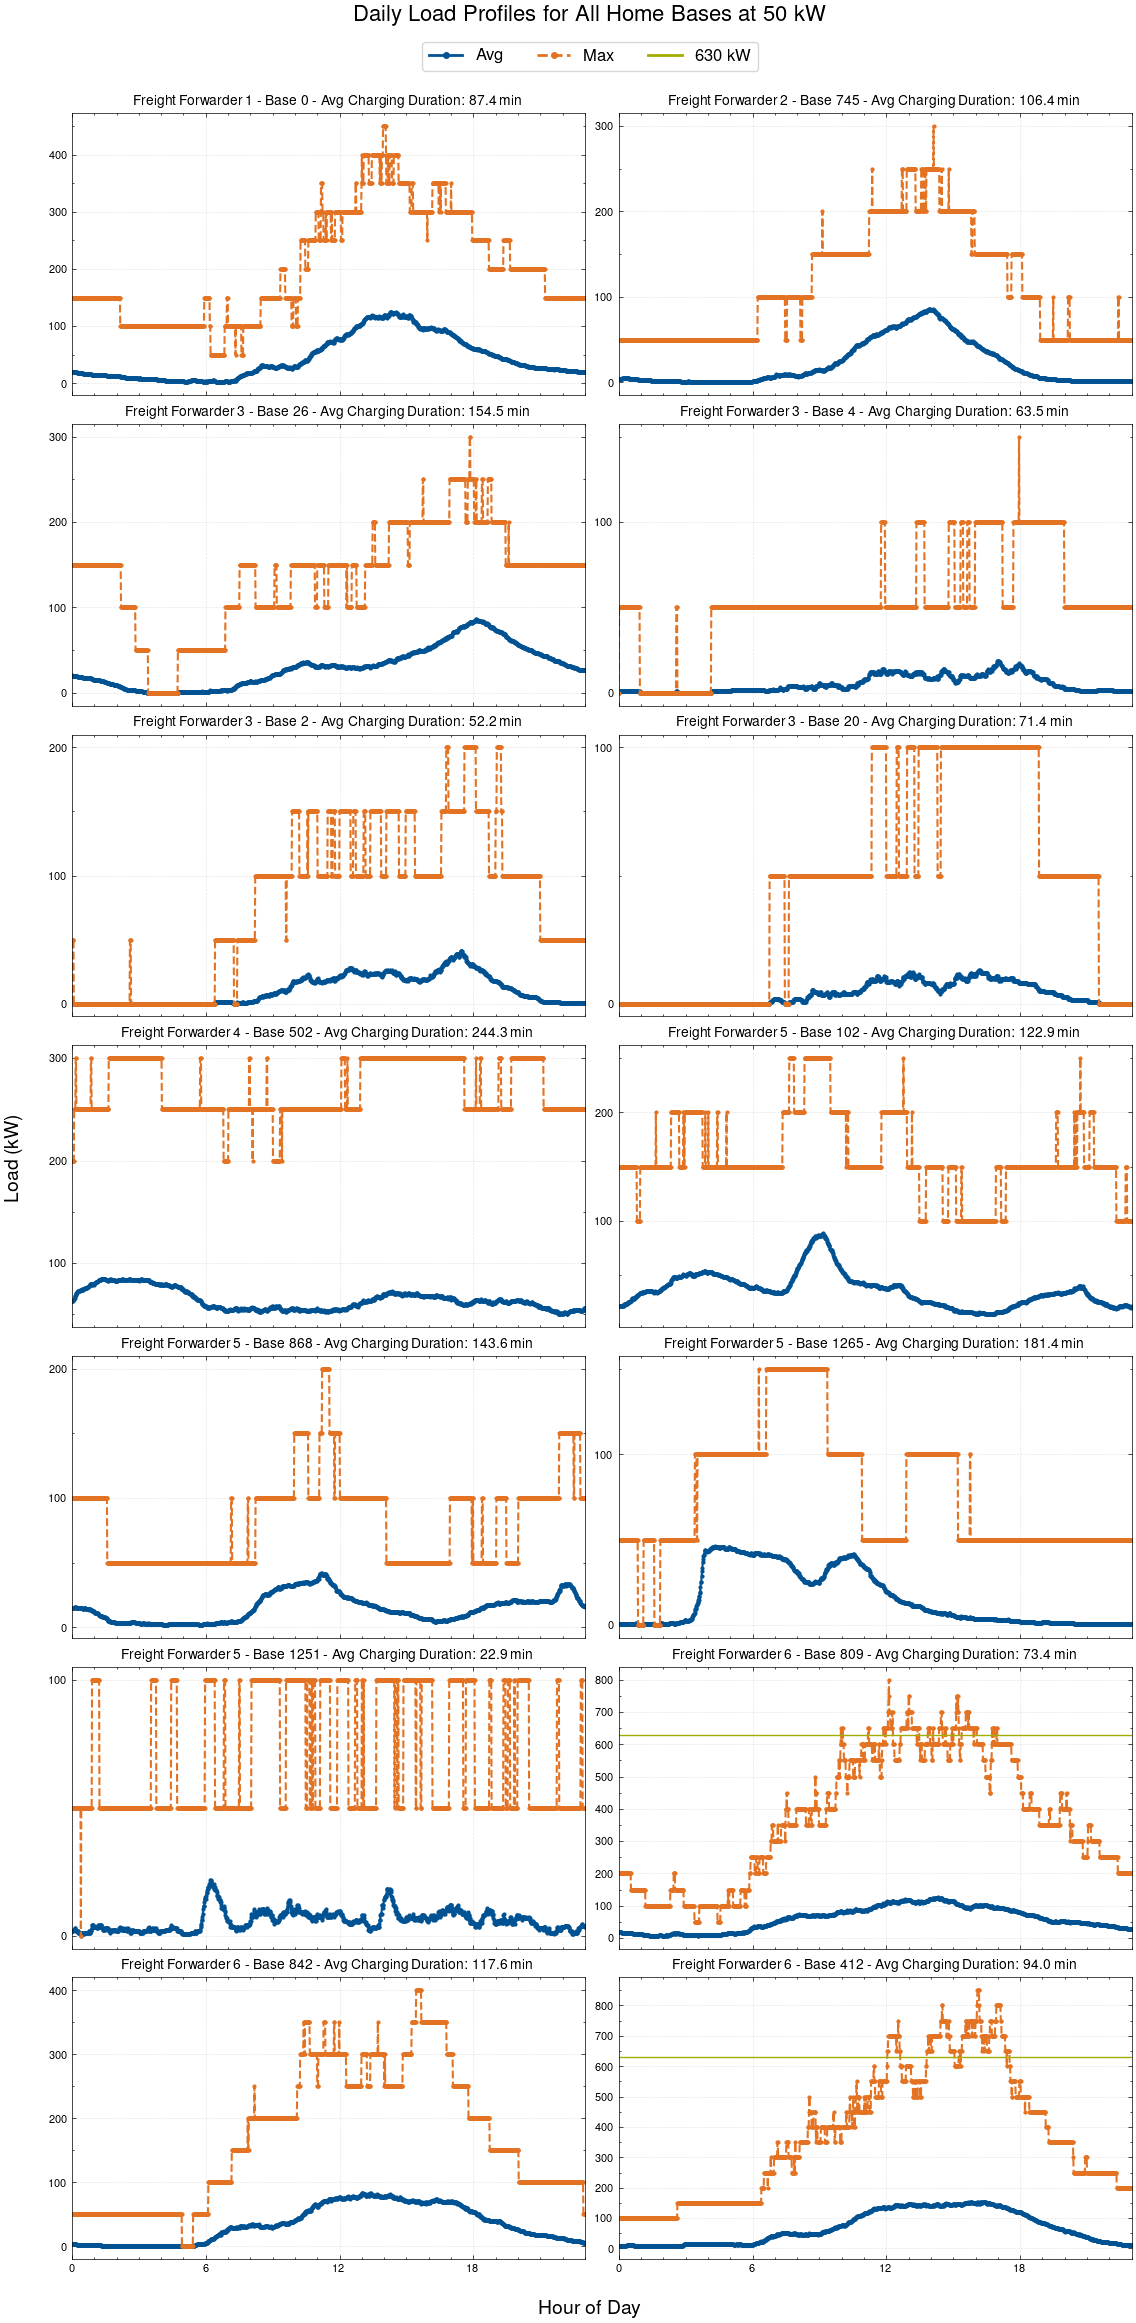


CID 0:
  Number of active days: 132
  Average maximum load: 199.27 kW
  Peak time: 14:18:00 (showing highest average load)
  Peak average load: 125.19 kW

CID 745:
  Number of active days: 161
  Average maximum load: 107.95 kW
  Peak time: 13:57:00 (showing highest average load)
  Peak average load: 86.34 kW

CID 26:
  Number of active days: 131
  Average maximum load: 136.56 kW
  Peak time: 18:07:00 (showing highest average load)
  Peak average load: 86.26 kW

CID 4:
  Number of active days: 63
  Average maximum load: 51.08 kW
  Peak time: 16:59:00 (showing highest average load)
  Peak average load: 18.85 kW

CID 2:
  Number of active days: 113
  Average maximum load: 74.83 kW
  Peak time: 17:27:00 (showing highest average load)
  Peak average load: 41.15 kW

CID 20:
  Number of active days: 79
  Average maximum load: 43.58 kW
  Peak time: 16:10:00 (showing highest average load)
  Peak average load: 13.29 kW

CID 502:
  Number of active days: 140
  Average maximum load: 265.49 kW
  P

In [12]:
# Call the function with all load profiles at once
stats = dv.plot_load_profiles_grid_thesis(load_profiles, charging_powers, charging_durations)

# Print statistics for each CID
for cid, cid_stats in stats.items():
    print(f"\nCID {cid}:")
    print(f"  Number of active days: {cid_stats['active_days']}")
    print(f"  Average maximum load: {cid_stats['avg_max_load']:.2f} kW")
    if cid_stats['peak_time']:
        print(f"  Peak time: {cid_stats['peak_time']} (showing highest average load)")
    print(f"  Peak average load: {cid_stats['peak_avg_load']:.2f} kW")



0


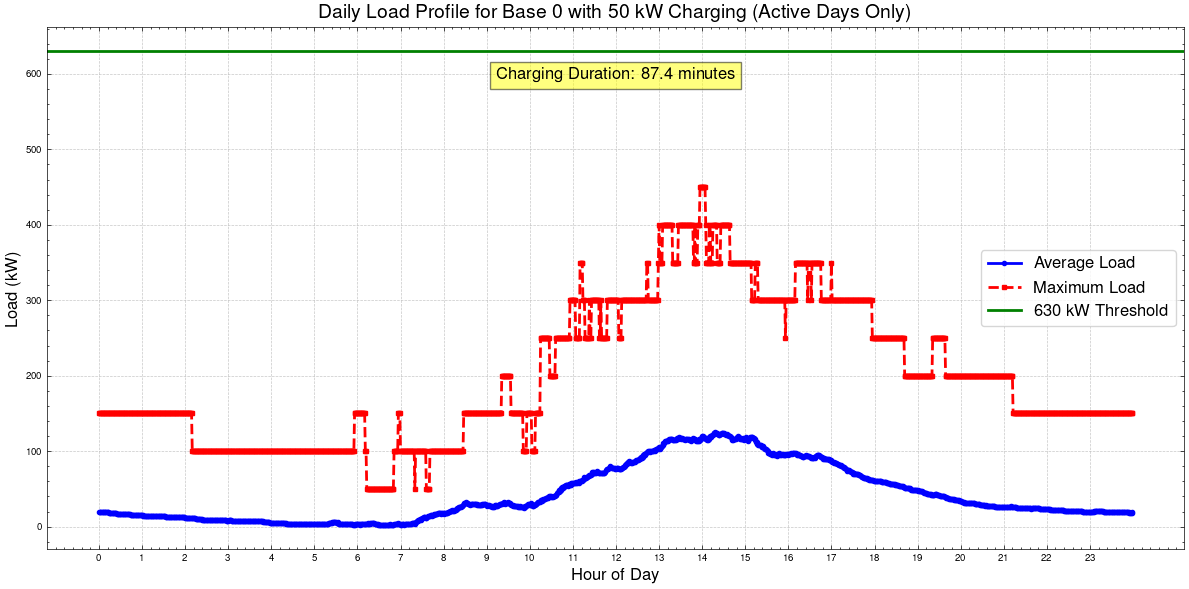

Number of active days: 132
Average maximum load: 199.27 kW
Peak time: 14:18:00 (showing highest average load)
Peak average load: 125.19 kW


745


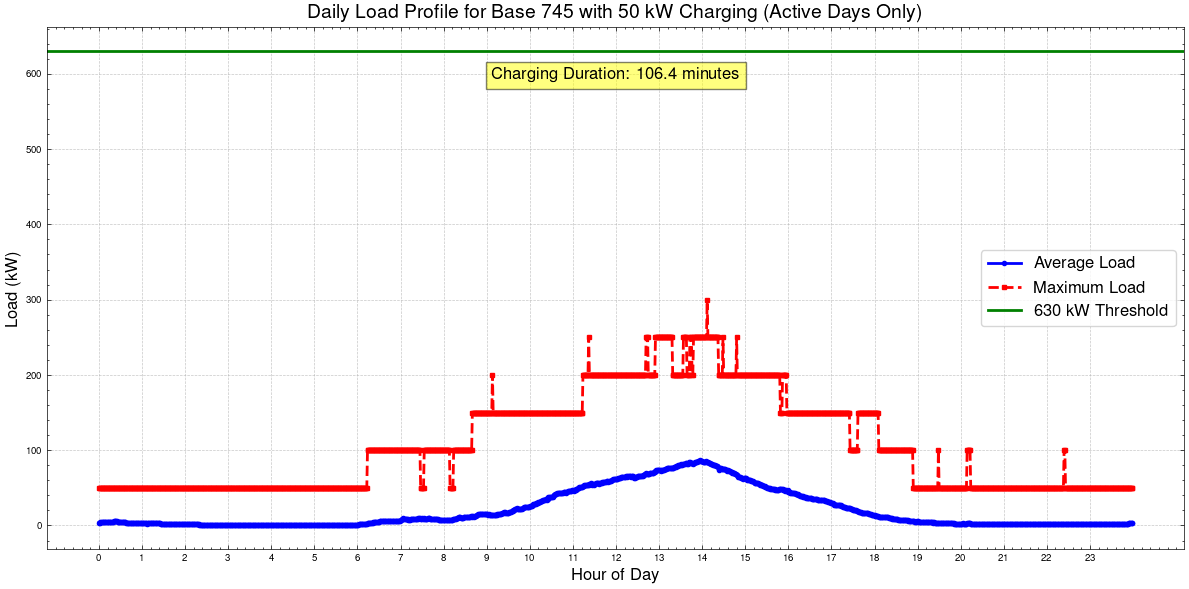

Number of active days: 161
Average maximum load: 107.95 kW
Peak time: 13:57:00 (showing highest average load)
Peak average load: 86.34 kW


26


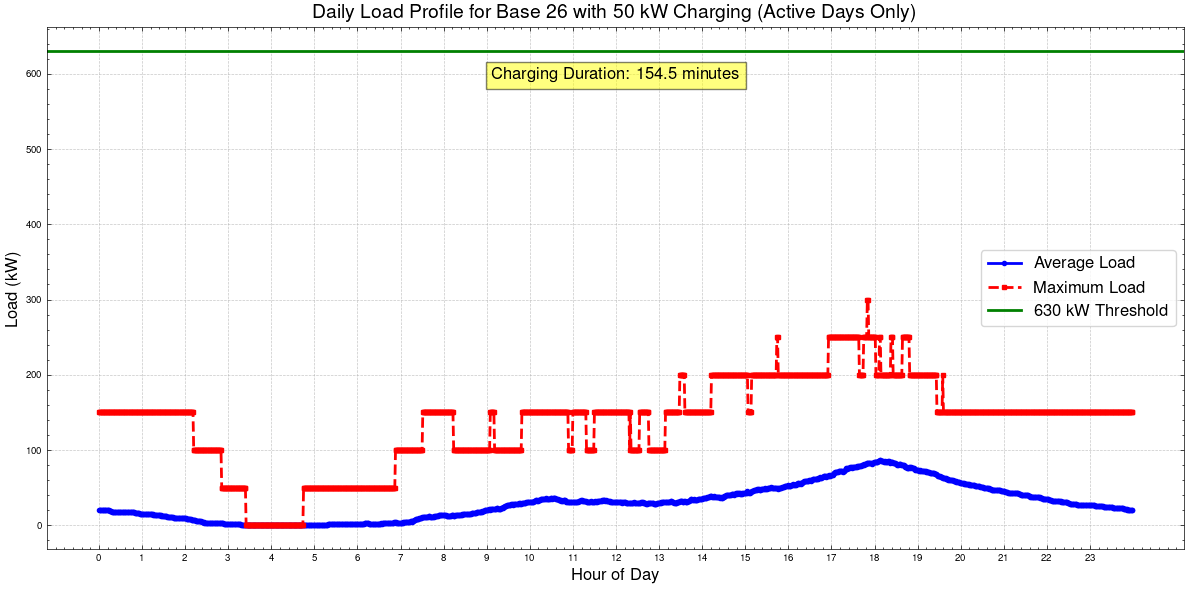

Number of active days: 131
Average maximum load: 136.56 kW
Peak time: 18:07:00 (showing highest average load)
Peak average load: 86.26 kW


4


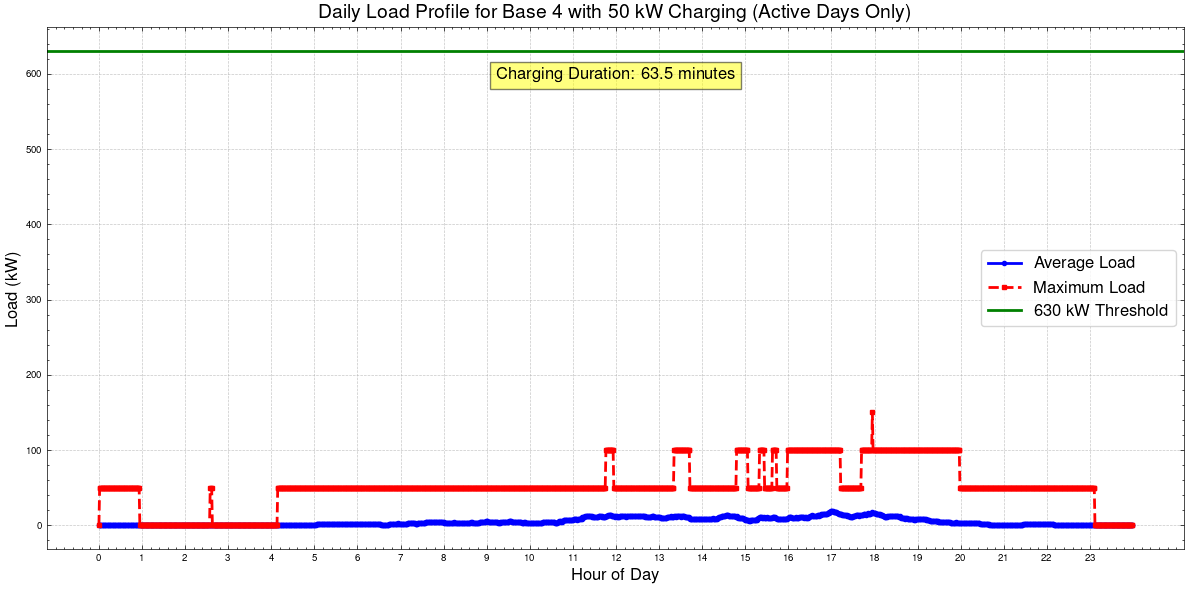

Number of active days: 63
Average maximum load: 51.08 kW
Peak time: 16:59:00 (showing highest average load)
Peak average load: 18.85 kW


2


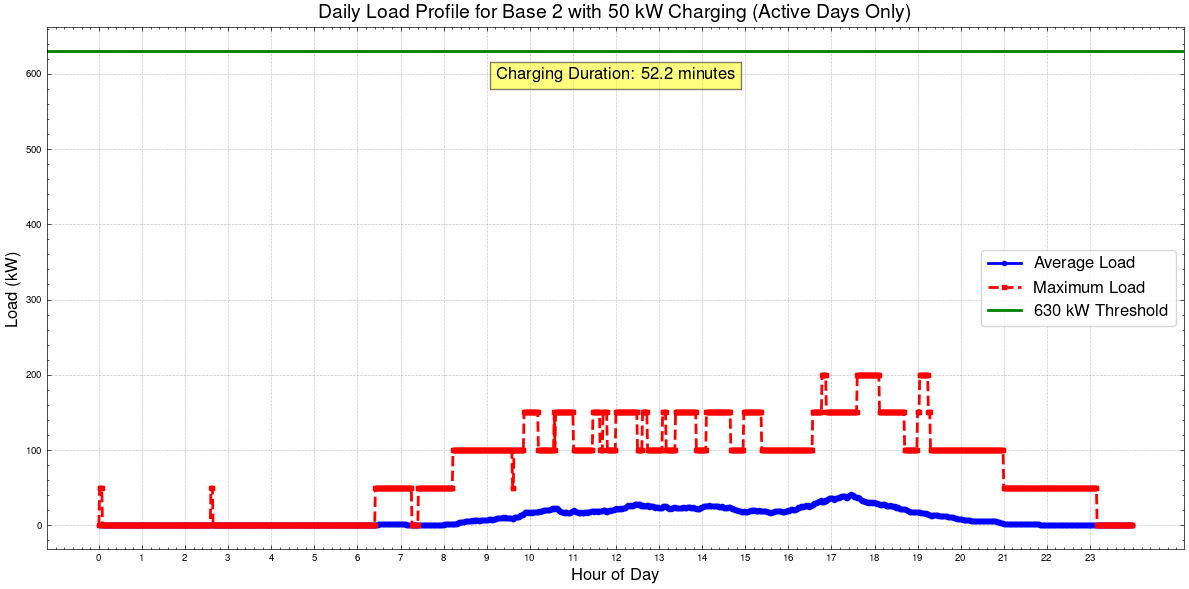

Number of active days: 113
Average maximum load: 74.83 kW
Peak time: 17:27:00 (showing highest average load)
Peak average load: 41.15 kW


20


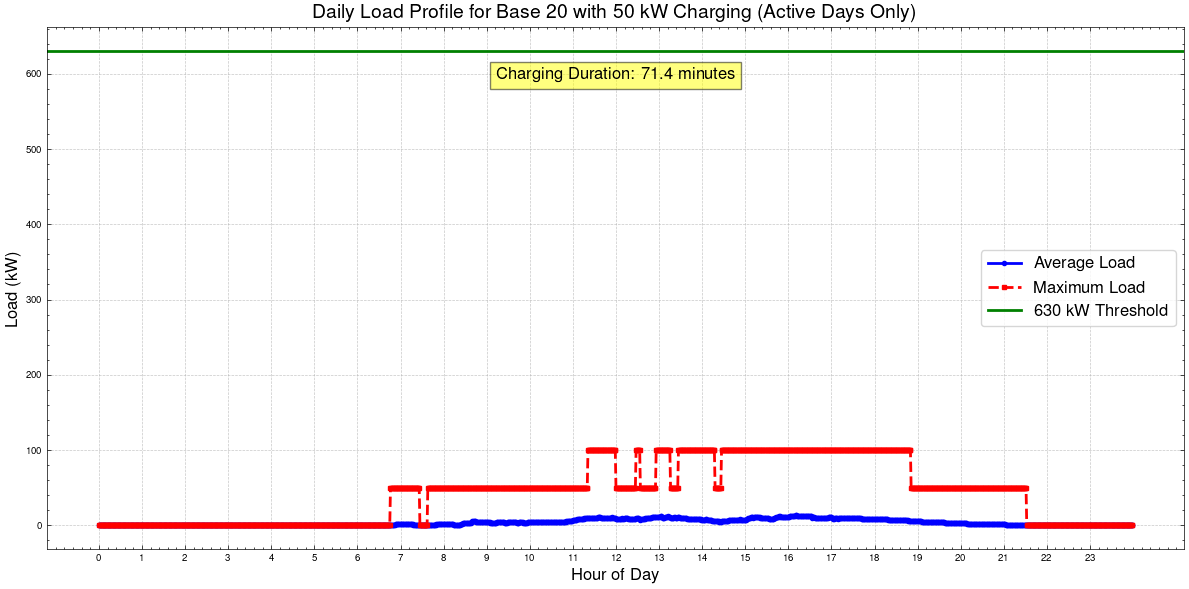

Number of active days: 79
Average maximum load: 43.58 kW
Peak time: 16:10:00 (showing highest average load)
Peak average load: 13.29 kW


502


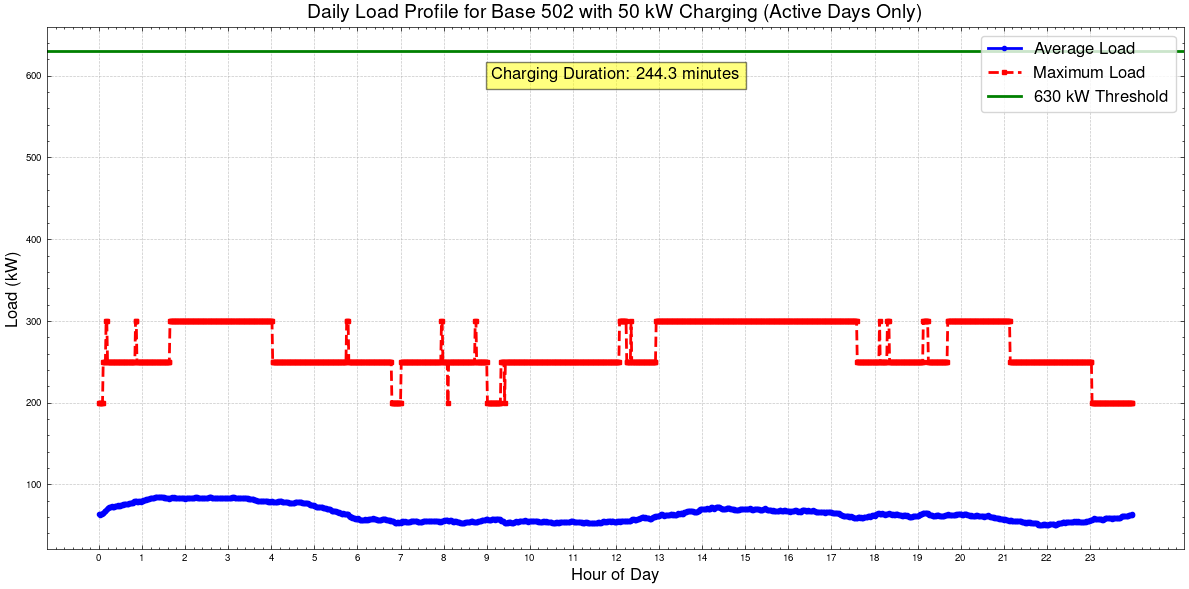

Number of active days: 140
Average maximum load: 265.49 kW
Peak time: 01:19:00 (showing highest average load)
Peak average load: 84.89 kW


102


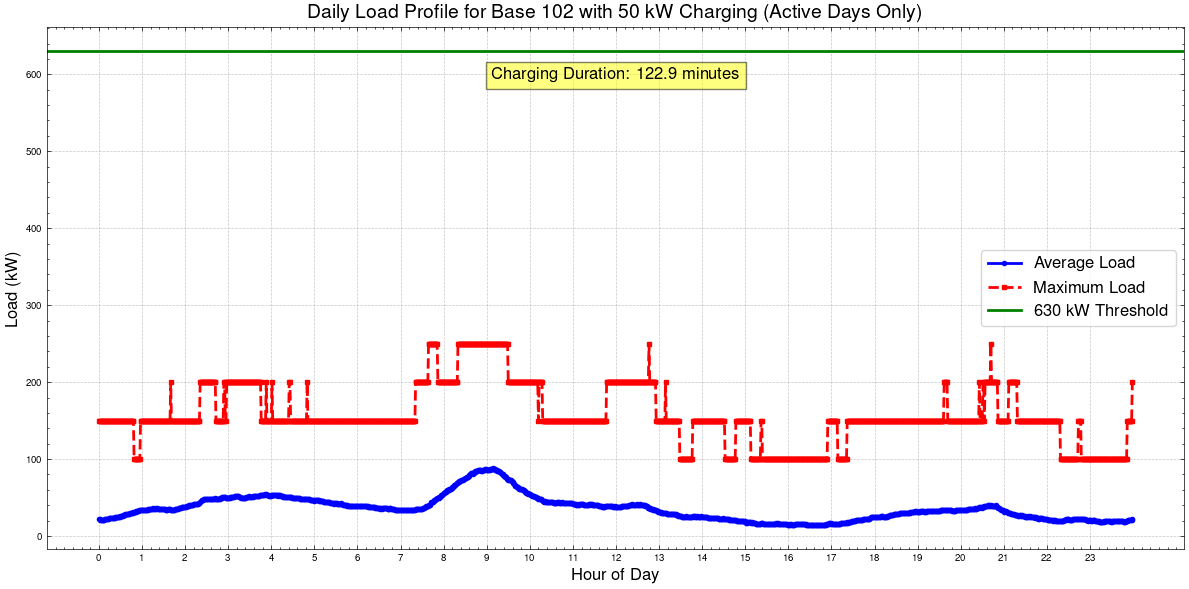

Number of active days: 204
Average maximum load: 156.91 kW
Peak time: 09:09:00 (showing highest average load)
Peak average load: 88.67 kW


868


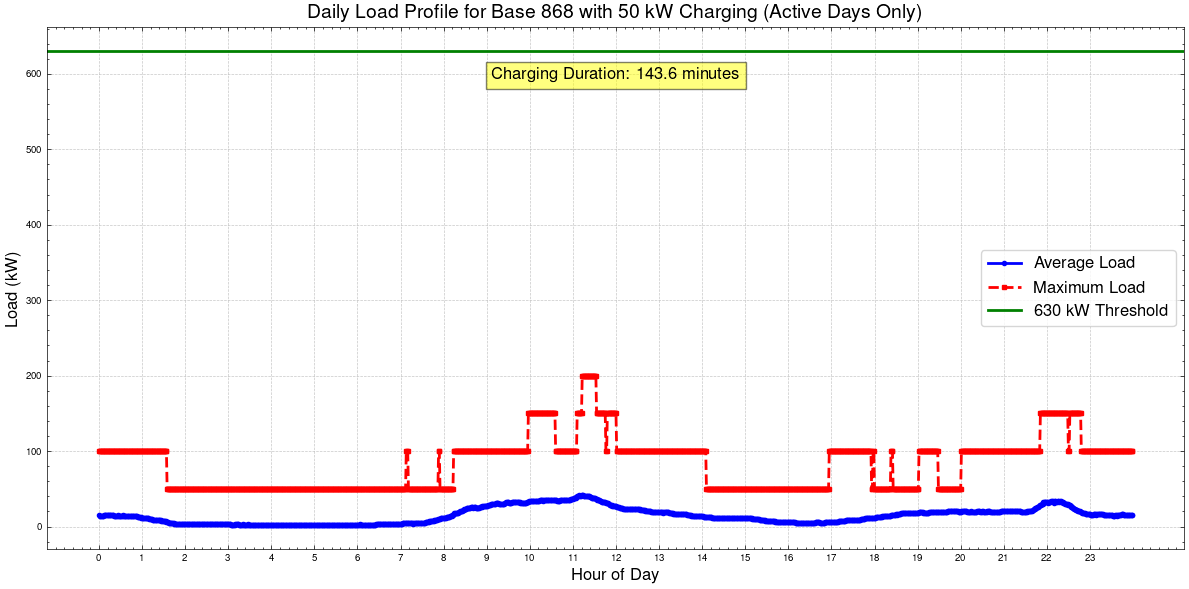

Number of active days: 118
Average maximum load: 82.92 kW
Peak time: 11:09:00 (showing highest average load)
Peak average load: 41.88 kW


1265


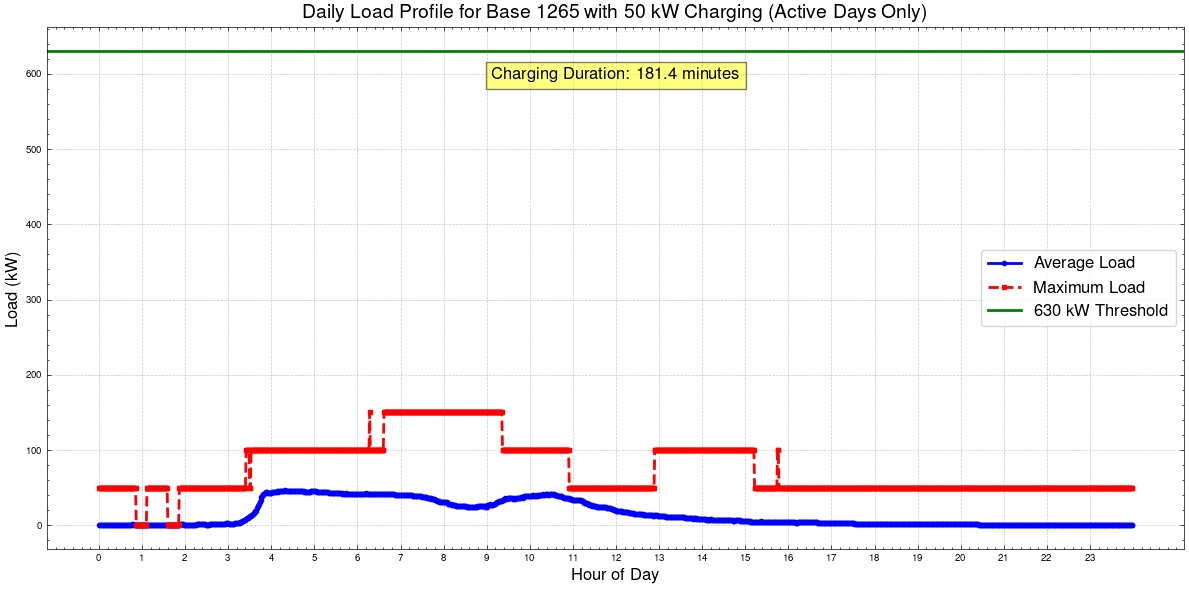

Number of active days: 133
Average maximum load: 75.14 kW
Peak time: 04:19:00 (showing highest average load)
Peak average load: 46.21 kW


1251


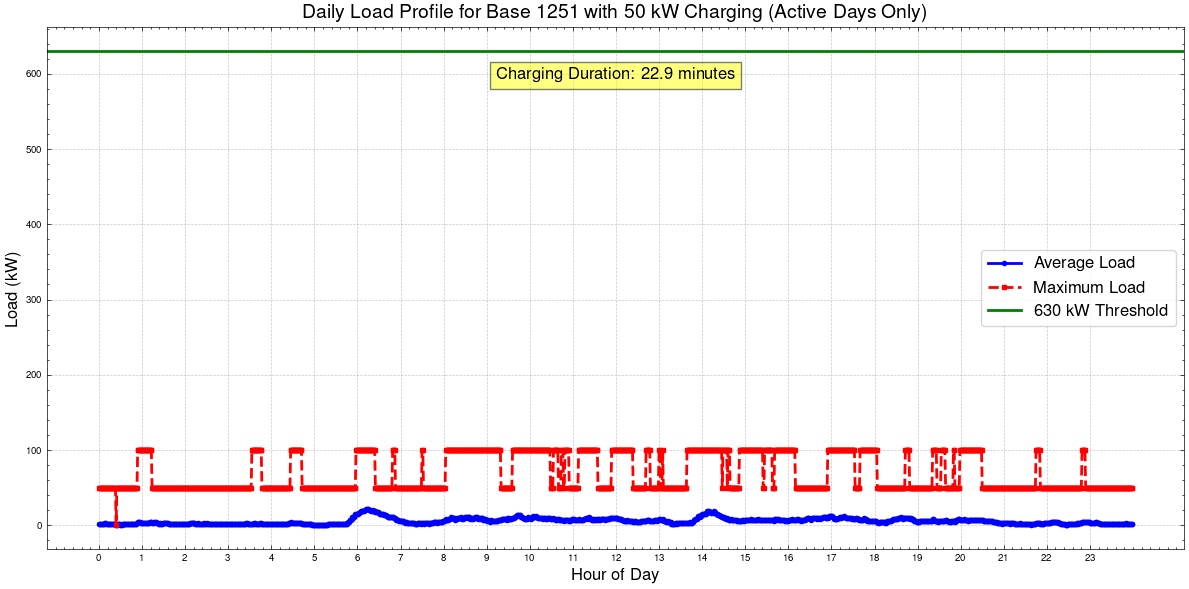

Number of active days: 88
Average maximum load: 69.06 kW
Peak time: 06:12:00 (showing highest average load)
Peak average load: 21.84 kW


809


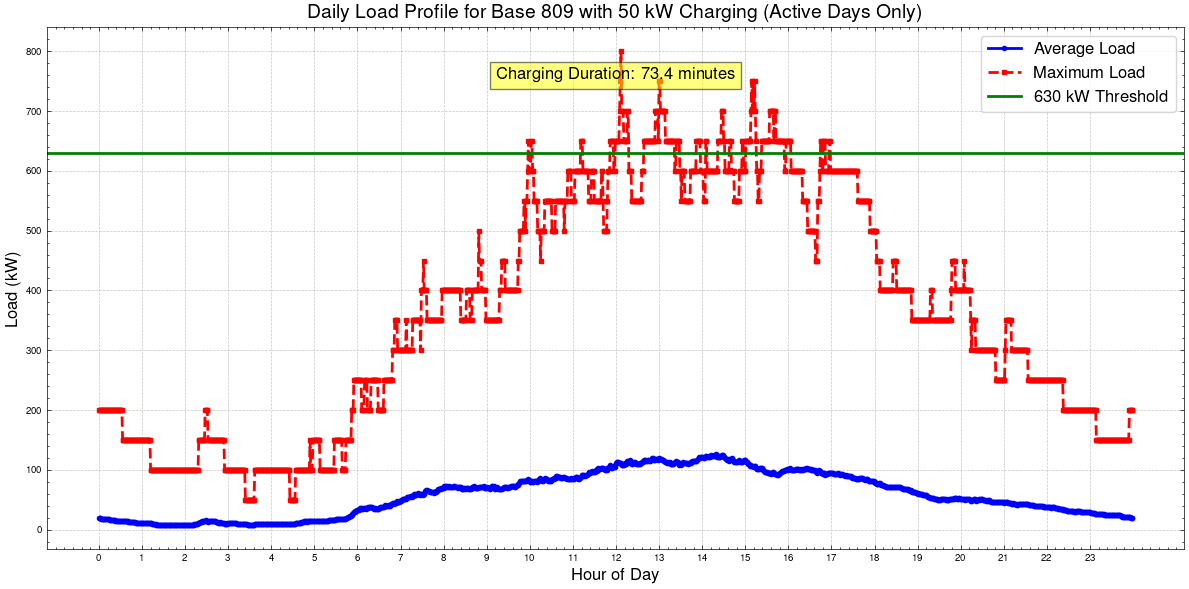

Number of active days: 102
Average maximum load: 363.40 kW
Peak time: 14:19:00 (showing highest average load)
Peak average load: 125.74 kW


842


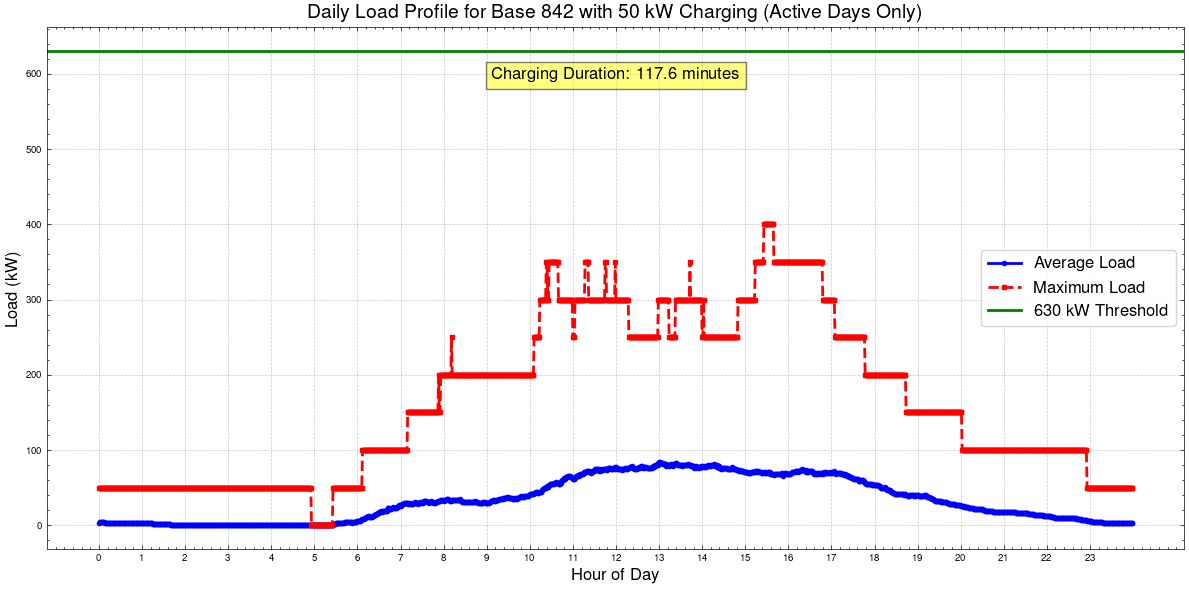

Number of active days: 83
Average maximum load: 164.69 kW
Peak time: 13:00:00 (showing highest average load)
Peak average load: 83.73 kW


412


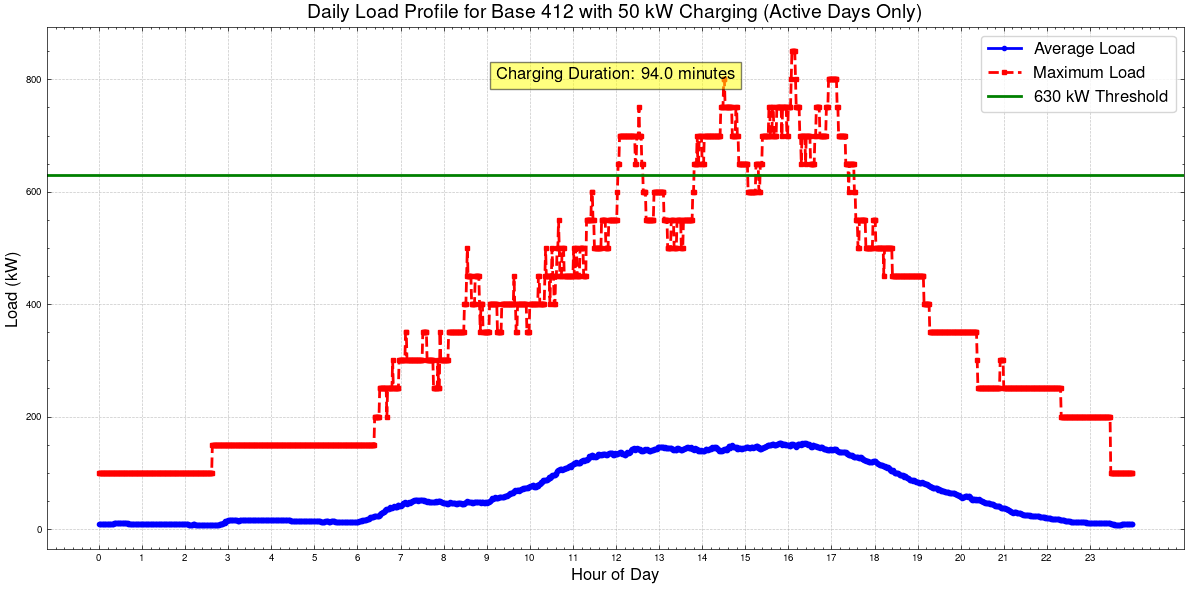

Number of active days: 106
Average maximum load: 362.71 kW
Peak time: 15:48:00 (showing highest average load)
Peak average load: 153.30 kW


In [14]:
for idx, load_profile in load_profiles.items():
    print('\n')
    print(idx)
    stats = dv.plot_load_profile(load_profile, idx, charging_powers, charging_durations[idx])

    print(f"Number of active days: {stats['active_days']}")
    print(f"Average maximum load: {stats['avg_max_load']:.2f} kW")
    print(f"Peak time: {stats['peak_time']} (showing highest average load)")
    print(f"Peak average load: {stats['peak_avg_load']:.2f} kW")